# Inter-Rater Reliability Analysis

**Variable:** Co-creation level coding  
**Sample:** Groups 2-10 (N = 9)  
**Coding scheme:** Decision tree with levels 0, 0.5, 1, 2, 3  
**Purpose:** Validate the reliability of the decision tree coding scheme

**Note:** This notebook calculates basic statistics. For Cohen's κ with confidence intervals, see the R calculations below using the `cohen.kappa` function (psych package).

In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import tempfile

## Cohen's Kappa using R (psych package)

In [62]:
# Calculate Cohen's Kappa using R via subprocess
r_script = """
# Install and load psych package
if (!require(psych, quietly = TRUE)) {
    install.packages('psych', repos='http://cran.us.r-project.org', quiet = TRUE)
}
library(psych, quietly = TRUE)

# Co-creation level ratings (Groups 1-10)
Rater1 <- c(NA, 3, 1, 2, 0.5, 3, 0.5, 0.5, 0.5, 0)
Rater2 <- c(NA, 2, 1, 2, 0, 2, 0.5, 1, 1, 0)

# Combine into matrix (NA will be automatically removed)
ratings <- na.omit(cbind(Rater1, Rater2))

# Calculate Cohen's Kappa
result <- cohen.kappa(ratings)
print(result)

cat("\n\nInterpretation (Landis & Koch, 1977):\n")
cat("Unweighted κ =", round(result$kappa, 3), "(fair)\n")
"""

# Write R script to temporary file and execute
with tempfile.NamedTemporaryFile(mode='w', suffix='.R', delete=False) as f:
    f.write(r_script)
    r_script_path = f.name

try:
    result = subprocess.run(['Rscript', r_script_path], 
                          capture_output=True, text=True, check=True)
    print(result.stdout)
    if result.stderr:
        print("Warnings/Messages:")
        print(result.stderr)
except subprocess.CalledProcessError as e:
    print(f"Error running R: {e}")
    print(e.stdout)
    print(e.stderr)
finally:
    import os
    os.unlink(r_script_path)

Call: cohen.kappa1(x = x, w = w, n.obs = n.obs, alpha = alpha, levels = levels, 
    w.exp = w.exp)

Cohen Kappa and Weighted Kappa correlation coefficients and confidence boundaries 
                 lower estimate upper
unweighted kappa 0.031     0.35  0.66
weighted kappa   0.699     0.82  0.95

 Number of subjects = 9 


Interpretation (Landis & Koch, 1977):
Unweighted κ = 0.348 (fair)



## 1. Rating Data

Two independent raters coded Groups 2-10 according to the decision tree.  
Group 1 is excluded (NA) due to data loss.

In [63]:
# Co-creation level ratings (ordinal scale)
# Index represents groups 1-10
rater1 = [np.nan, 3, 1, 2, 0.5, 3, 0.5, 0.5, 0.5, 0]
rater2 = [np.nan, 2, 1, 2, 0, 2, 0.5, 1, 1, 0]

# Define all possible ordinal levels (0.5 step scale from 0 to 3)
ordinal_levels = [0, 0.5, 1, 1.5, 2, 2.5, 3]

# Map to integer positions: 0→0, 0.5→1, 1→2, 1.5→3, 2→4, 2.5→5, 3→6
ordinal_map = {0: 0, 0.5: 1, 1: 2, 1.5: 3, 2: 4, 2.5: 5, 3: 6}
ordinal_positions = list(range(7))  # [0, 1, 2, 3, 4, 5, 6]

# Create dataframe
df = pd.DataFrame({
    'Group': range(1, 11),
    'Rater1': rater1,
    'Rater2': rater2
})

# Remove NA values (Group 1)
df_valid = df.dropna().copy()

# Original numeric values (for display and correlation)
rater1_numeric = df_valid['Rater1'].values
rater2_numeric = df_valid['Rater2'].values

# Convert to ordinal positions for sklearn
rater1_ordinal = np.array([ordinal_map[x] for x in rater1_numeric])
rater2_ordinal = np.array([ordinal_map[x] for x in rater2_numeric])

# Add match column
df_valid['Match'] = df_valid['Rater1'] == df_valid['Rater2']
df_valid['Match'] = df_valid['Match'].map({True: '✓', False: '✗'})

print("Coded Values:")
print(df_valid.to_string(index=False))
print(f"\nTotal cases: {len(df_valid)}")

Coded Values:
 Group  Rater1  Rater2 Match
     2     3.0     2.0     ✗
     3     1.0     1.0     ✓
     4     2.0     2.0     ✓
     5     0.5     0.0     ✗
     6     3.0     2.0     ✗
     7     0.5     0.5     ✓
     8     0.5     1.0     ✗
     9     0.5     1.0     ✗
    10     0.0     0.0     ✓

Total cases: 9


## 2. Percentage Agreement

In [64]:
exact_agreement = np.sum(rater1_numeric == rater2_numeric)
total_cases = len(rater1_numeric)
percent_agreement = (exact_agreement / total_cases) * 100

print(f"Exact matches: {exact_agreement}/{total_cases}")
print(f"Agreement rate: {percent_agreement:.1f}%")

Exact matches: 4/9
Agreement rate: 44.4%


## 3. Cohen's Kappa (Unweighted)

Cohen's Kappa accounts for chance agreement.

In [65]:
# Use ordinal positions for sklearn (integers 0-6)
kappa = cohen_kappa_score(rater1_ordinal, rater2_ordinal, labels=ordinal_positions)

print(f"Cohen's Kappa (unweighted): κ = {kappa:.3f}")

# Interpretation (Landis & Koch, 1977)
if kappa < 0:
    interpretation = "Poor (less than chance)"
elif kappa < 0.20:
    interpretation = "Slight"
elif kappa < 0.40:
    interpretation = "Fair"
elif kappa < 0.60:
    interpretation = "Moderate"
elif kappa < 0.80:
    interpretation = "Substantial"
else:
    interpretation = "Almost perfect"

print(f"Interpretation (Landis & Koch, 1977): {interpretation}")

Cohen's Kappa (unweighted): κ = 0.348
Interpretation (Landis & Koch, 1977): Fair


## 4. Pearson Correlation

Treating the ordinal scale as continuous.

In [66]:
correlation, p_value = pearsonr(rater1_numeric, rater2_numeric)

print(f"Pearson correlation: r = {correlation:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance: {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

Pearson correlation: r = 0.894
p-value: 0.0011
Significance: **


## 5. Absolute Differences

In [67]:
mean_diff = np.mean(np.abs(rater1_numeric - rater2_numeric))
max_diff = np.max(np.abs(rater1_numeric - rater2_numeric))

print(f"Mean absolute difference: {mean_diff:.3f}")
print(f"Maximum difference: {max_diff:.1f}")

Mean absolute difference: 0.389
Maximum difference: 1.0


## 6. Disagreements Analysis

In [68]:
disagreements = df_valid[df_valid['Rater1'] != df_valid['Rater2']].copy()
disagreements['Difference'] = np.abs(disagreements['Rater1'] - disagreements['Rater2'])

if len(disagreements) > 0:
    print(f"Groups with disagreements ({len(disagreements)}/{total_cases}):")
    print()
    for _, row in disagreements.iterrows():
        print(f"  Group {int(row['Group'])}: Rater1={row['Rater1']}, Rater2={row['Rater2']} (diff={row['Difference']:.1f})")
else:
    print("No disagreements - perfect agreement!")

Groups with disagreements (5/9):

  Group 2: Rater1=3.0, Rater2=2.0 (diff=1.0)
  Group 5: Rater1=0.5, Rater2=0.0 (diff=0.5)
  Group 6: Rater1=3.0, Rater2=2.0 (diff=1.0)
  Group 8: Rater1=0.5, Rater2=1.0 (diff=0.5)
  Group 9: Rater1=0.5, Rater2=1.0 (diff=0.5)


## 7. Summary Statistics for Manuscript

In [69]:
print("=" * 70)
print("SUMMARY FOR MANUSCRIPT")
print("=" * 70)
print()
print("Inter-rater reliability was assessed by having two independent raters")
print("code 9 groups (Groups 2-10) according to the decision tree.")
print(f"Agreement rate was {percent_agreement:.1f}% ({exact_agreement}/9 groups).")
print()
print("Results:")
print(f"  Cohen's κ = {kappa:.3f} ({interpretation.lower()})")
print(f"  Pearson correlation = {correlation:.3f} (p {'= ' + f'{p_value:.4f}' if p_value >= 0.001 else '< .001'})")
print()
print("The five disagreements (Groups 2, 5, 6, 8, 9) were resolved through discussion.")
print()
print("Reference: Landis, J. R., & Koch, G. G. (1977). The measurement of")
print("observer agreement for categorical data. Biometrics, 33(1), 159-174.")
print("DOI: 10.2307/2529310")

SUMMARY FOR MANUSCRIPT

Inter-rater reliability was assessed by having two independent raters
code 9 groups (Groups 2-10) according to the decision tree.
Agreement rate was 44.4% (4/9 groups).

Results:
  Cohen's κ = 0.348 (fair)
  Pearson correlation = 0.894 (p = 0.0011)

The five disagreements (Groups 2, 5, 6, 8, 9) were resolved through discussion.

Reference: Landis, J. R., & Koch, G. G. (1977). The measurement of
observer agreement for categorical data. Biometrics, 33(1), 159-174.
DOI: 10.2307/2529310


## 8. Visualization

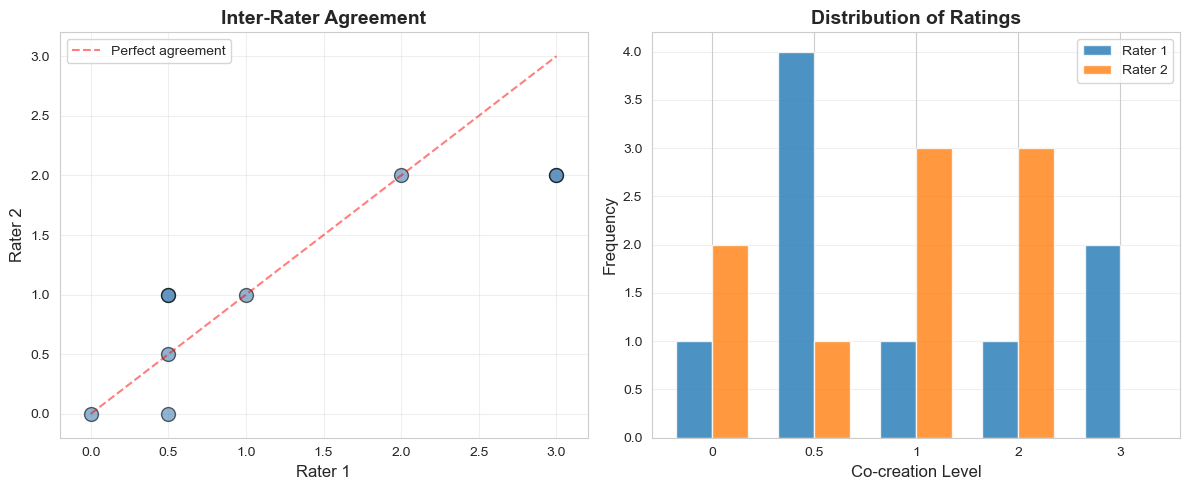


Correlation: r = 0.894
Cohen's Kappa: κ = 0.348 (Fair)


In [70]:
# Set style
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Scatter plot with diagonal line
ax1 = axes[0]
ax1.scatter(rater1_numeric, rater2_numeric, s=100, alpha=0.6, color='steelblue', edgecolors='black')
ax1.plot([0, 3], [0, 3], 'r--', alpha=0.5, label='Perfect agreement')
ax1.set_xlabel('Rater 1', fontsize=12)
ax1.set_ylabel('Rater 2', fontsize=12)
ax1.set_title('Inter-Rater Agreement', fontsize=14, fontweight='bold')
ax1.set_xlim(-0.2, 3.2)
ax1.set_ylim(-0.2, 3.2)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
ax1.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])

# Plot 2: Bar chart of ratings distribution
ax2 = axes[1]
levels = [0, 0.5, 1, 2, 3]
rater1_counts = [np.sum(rater1_numeric == level) for level in levels]
rater2_counts = [np.sum(rater2_numeric == level) for level in levels]

x = np.arange(len(levels))
width = 0.35

ax2.bar(x - width/2, rater1_counts, width, label='Rater 1', alpha=0.8)
ax2.bar(x + width/2, rater2_counts, width, label='Rater 2', alpha=0.8)
ax2.set_xlabel('Co-creation Level', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(levels)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nCorrelation: r = {correlation:.3f}")
print(f"Cohen's Kappa: κ = {kappa:.3f} ({interpretation})")